# **Holiday Package Prediciton**

**1. Problem statement.**

"Trips & Travel.Com" company wants to enable and establish a viable business model to expand the customer base. One of the ways to expand the customer base is to introduce a new offering of packages. Currently, there are 5 types of packages the company is offering * Basic, Standard, Deluxe, Super Deluxe, King. Looking at the data of the last year, we observed that 18% of the customers purchased the packages. However, the marketing cost was quite high because customers were contacted at random without looking at the available information. The company is now planning to launch a new product i.e. Wellness Tourism Package. Wellness Tourism is defined as Travel that allows the traveler to maintain, enhance or kick-start a healthy lifestyle, and support or increase one's sense of well-being. However, this time company wants to harness the available data of existing and potential customers to make the marketing expenditure more efficient.

**2. Data Collection.**
The Dataset is collected from https://www.kaggle.com/datasets/susant4learning/holiday-package-purchase-prediction The data consists of 20 column and 4888 rows.

## **Business Problem Statement**

**Company:** `trips&travel.com`

The company wants to launch a new **Wellness Tourism Package** and, instead of contacting customers
at random (which was costly and inefficient — only ~18% conversion previously), wants to use
**customer data to predict who is likely to purchase** the new package. This lets marketing spend
be targeted efficiently.

>  This is a **binary classification problem**: will a customer purchase the package (`1`) or not (`0`)?

# **1. Import Libraries**

In [1]:
# Import Required Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Model Selection
# Split the dataset into training and testing sets
# RandomizedSearchCV performs efficient hyperparameter tuning
from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV
)


# Data Preprocessing
# Convert categorical features into numerical format
from sklearn.preprocessing import OneHotEncoder

# Standardize numerical features (mean = 0, standard deviation = 1)
from sklearn.preprocessing import StandardScaler

# Apply different preprocessing steps to different feature columns
from sklearn.compose import ColumnTransformer


# Machine Learning Models
# Ensemble model based on multiple Decision Trees
from sklearn.ensemble import RandomForestClassifier

# Single Decision Tree classifier
from sklearn.tree import DecisionTreeClassifier

# Logistic Regression classifier (used as a baseline model)
from sklearn.linear_model import LogisticRegression

# Model Evaluation
from sklearn.metrics import (
    accuracy_score,              # Overall classification accuracy
    precision_score,             # Precision = TP / (TP + FP)
    recall_score,                # Recall = TP / (TP + FN)
    f1_score,                    # Harmonic mean of Precision and Recall
    roc_auc_score,               # Area Under the ROC Curve
    roc_curve,                   # False Positive Rate vs True Positive Rate
    confusion_matrix,            # Confusion Matrix values
    ConfusionMatrixDisplay,      # Visualize the Confusion Matrix
    classification_report        # Precision, Recall, F1-Score, and Support
)


# Display & Reproducibility
# Display all DataFrame columns when printing
pd.set_option('display.max_columns', 50)

# Ensure reproducible results for NumPy-based random operations
np.random.seed(42)

# **2. Load the Travel (Holiday Package) Dataset**



In [2]:
df = pd.read_csv("Travel.csv")

print("Keys available:", list(df.keys()))   # column names
print("\nData shape:", df.shape)             # (rows, columns)
df.head()

Keys available: ['CustomerID', 'ProdTaken', 'Age', 'TypeofContact', 'CityTier', 'DurationOfPitch', 'Occupation', 'Gender', 'NumberOfPersonVisiting', 'NumberOfFollowups', 'ProductPitched', 'PreferredPropertyStar', 'MaritalStatus', 'NumberOfTrips', 'Passport', 'PitchSatisfactionScore', 'OwnCar', 'NumberOfChildrenVisiting', 'Designation', 'MonthlyIncome']

Data shape: (4888, 20)


,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


The dataset contains **4,888 rows and 20 columns**, including the target column **`ProdTaken`**, where **1** indicates that the customer purchased the holiday package and **0** indicates that they did not.

The remaining **19 features** describe different aspects of each customer, including:

- **Demographic information:** `Age`, `Gender`, `MaritalStatus`, `Occupation`, `Designation`, and `MonthlyIncome`.
- **Sales interaction details:** `TypeofContact`, `DurationOfPitch`, `NumberOfFollowups`, `PitchSatisfactionScore`, and `ProductPitched`.
- **Travel preferences and customer profile:** `CityTier`, `PreferredPropertyStar`, `NumberOfTrips`, `NumberOfPersonVisiting`, `NumberOfChildrenVisiting`, `Passport`, and `OwnCar`.

These features will be used to predict whether a customer is likely to purchase a holiday package.

## 3. **Exploratory Data Analysis (EDA) & Data Cleaning**


**3.1 Check Missing Value**s

In [3]:
# Count missing (NaN) values per column
df.isnull().sum()

,0
CustomerID,0
ProdTaken,0
Age,226
TypeofContact,25
CityTier,0
DurationOfPitch,251
Occupation,0
Gender,0
NumberOfPersonVisiting,0
NumberOfFollowups,45


The dataset contains missing values in **8 columns**:

- `Age`
- `TypeofContact`
- `DurationOfPitch`
- `NumberOfFollowups`
- `PreferredPropertyStar`
- `NumberOfTrips`
- `NumberOfChildrenVisiting`
- `MonthlyIncome`

The percentage of missing values in each of these columns is **relatively small (less than about 5%)**, so removing rows would unnecessarily reduce the dataset size. A better approach is to **impute** the missing values:

- Use the **median** for numerical columns, as it is robust to outliers.
- Use the **mode (most frequent value)** for categorical columns, since it preserves the most common category.

The exact percentage of missing values in each column is calculated in the next step.

**3.2 Check Categorical Columns for Spelling/Consistency Issues**

In [4]:
# Inspect category labels for typos / inconsistent spellings before encoding
print(df['Gender'].value_counts())
print()
print(df['TypeofContact'].value_counts())
print()
print(df['ProductPitched'].value_counts())
print()
print(df['MaritalStatus'].value_counts())
print()
print(df['Designation'].value_counts())
print()
print(df['Occupation'].value_counts())

Gender
Male       2916
Female     1817
Fe Male     155
Name: count, dtype: int64

TypeofContact
Self Enquiry       3444
Company Invited    1419
Name: count, dtype: int64

ProductPitched
Basic           1842
Deluxe          1732
Standard         742
Super Deluxe     342
King             230
Name: count, dtype: int64

MaritalStatus
Married      2340
Divorced      950
Single        916
Unmarried     682
Name: count, dtype: int64

Designation
Executive         1842
Manager           1732
Senior Manager     742
AVP                342
VP                 230
Name: count, dtype: int64

Occupation
Salaried          2368
Small Business    2084
Large Business     434
Free Lancer          2
Name: count, dtype: int64


`Gender` has a `"Fe Male"` spelling variant, and `MaritalStatus` has
overlapping categories (`"Single"` and `"Unmarried"`). Let's fix both.

In [5]:
# Fix inconsistent category spellings so they aren't treated as separate classes
df['Gender'] = df['Gender'].replace('Fe Male', 'Female')                 # "Fe Male" -> "Female"
df['MaritalStatus'] = df['MaritalStatus'].replace('Single', 'Unmarried') # merge "Single" into "Unmarried"

print(df['Gender'].value_counts())
print()
print(df['MaritalStatus'].value_counts())

Gender
Male      2916
Female    1972
Name: count, dtype: int64

MaritalStatus
Married      2340
Unmarried    1598
Divorced      950
Name: count, dtype: int64


After cleaning the data, the categorical values become more consistent:

- **`Gender`** contains only **2 valid categories**: **Male** and **Female**.
- **`MaritalStatus`** combines **`Single`** and **`Unmarried`** into a single category, leaving **3 categories**:
  - `Married`
  - `Unmarried`
  - `Divorced`

This data cleaning step removes duplicate or inconsistent category names that represent the same meaning. As a result, the model learns from **consistent categories** instead of treating different spellings or labels as separate groups, leading to cleaner features and potentially better model performance.

**3.3 Handle Missing Values**

- **Numerical/Continuous columns** → fill with **median** (robust to outliers)
- **Categorical columns** → fill with **mode** (most frequent value)

In [6]:
# List columns that still have missing values, and what % of rows they affect
features_with_na = [f for f in df.columns if df[f].isnull().sum() >= 1]
print("Columns with missing values:", features_with_na)

for f in features_with_na:
    pct_missing = np.round(df[f].isnull().mean() * 100, 2)
    print(f"{f}: {pct_missing}% missing")

Columns with missing values: ['Age', 'TypeofContact', 'DurationOfPitch', 'NumberOfFollowups', 'PreferredPropertyStar', 'NumberOfTrips', 'NumberOfChildrenVisiting', 'MonthlyIncome']
Age: 4.62% missing
TypeofContact: 0.51% missing
DurationOfPitch: 5.14% missing
NumberOfFollowups: 0.92% missing
PreferredPropertyStar: 0.53% missing
NumberOfTrips: 2.86% missing
NumberOfChildrenVisiting: 1.35% missing
MonthlyIncome: 4.77% missing


`DurationOfPitch` has the highest missing rate at **5.14%**, followed by `Age`
(4.62%) and `MonthlyIncome` (4.77%). All others are under 3%. Since the maximum missing rate is
modest, median/mode imputation (rather than more complex methods like KNN-imputation) is a
low-risk, low-bias choice here.

```
#Age
df.Age.fillna(df.Age.median(), inplace=True)

#TypeofContract
df.TypeofContact.fillna(df.TypeofContact.mode()[0], inplace=True)

#DurationOfPitch
df.DurationOfPitch.fillna(df.DurationOfPitch.median(), inplace=True)

#NumberOfFollowups
df.NumberOfFollowups.fillna(df.NumberOfFollowups.mode()[0], inplace=True)

#PreferredPropertyStar
df.PreferredPropertyStar.fillna(df.PreferredPropertyStar.mode()[0], inplace=True)

#NumberOfTrips
df.NumberOfTrips.fillna(df.NumberOfTrips.median(), inplace=True)

#NumberOfChildrenVisiting
df.NumberOfChildrenVisiting.fillna(df.NumberOfChildrenVisiting.mode()[0], inplace=True)

#MonthlyIncome
df.MonthlyIncome.fillna(df.MonthlyIncome.median(), inplace=True)
```



In [7]:
# Impute (fill) missing values in each column
for f in features_with_na:

    # Check whether the current column is categorical
    if not pd.api.types.is_numeric_dtype(df[f]):

        # For categorical features, replace missing values
        # with the mode (most frequently occurring category).
        # mode()[0] returns the first mode if multiple modes exist.
        df[f] = df[f].fillna(df[f].mode()[0])

    else:
        # For numerical features, replace missing values
        # with the median. The median is preferred because
        # it is less affected by outliers and skewed data
        # than the mean.
        df[f] = df[f].fillna(df[f].median())

# Verify that all missing values have been handled
# A result of 0 means the dataset no longer contains any missing values.
print("Remaining missing values:", df.isnull().sum().sum())

Remaining missing values: 0


**3.4 Drop Irrelevant Columns & Create a Derived Feature**

- `CustomerID` is just a unique identifier — no predictive value, so we drop it.
- `NumberOfPersonVisiting` + `NumberOfChildrenVisiting` are combined into one derived feature: `TotalVisiting`.

In [8]:
# Remove the 'CustomerID' column
# CustomerID is a unique identifier for each customer and
# does not contain useful information for predicting whether
# a customer will purchase a holiday package.
df.drop('CustomerID', axis=1, inplace=True)

# Feature Engineering:
# Create a new feature called 'TotalVisiting' by combining
# the number of adults and children travelling together.
# This represents the total number of people in the travel group.
df['TotalVisiting'] = (
    df['NumberOfPersonVisiting'] +
    df['NumberOfChildrenVisiting']
)

# Remove the original columns since their information
# is now captured in the new 'TotalVisiting' feature.
# This helps reduce redundancy in the dataset.
df.drop(
    ['NumberOfPersonVisiting', 'NumberOfChildrenVisiting'],
    axis=1,
    inplace=True
)

df.head()

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,Designation,MonthlyIncome,TotalVisiting
0,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3.0,Deluxe,3.0,Unmarried,1.0,1,2,1,Manager,20993.0,3.0
1,0,49.0,Company Invited,1,14.0,Salaried,Male,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,Manager,20130.0,5.0
2,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,4.0,Basic,3.0,Unmarried,7.0,1,3,0,Executive,17090.0,3.0
3,0,33.0,Company Invited,1,9.0,Salaried,Female,3.0,Basic,3.0,Divorced,2.0,1,5,1,Executive,17909.0,3.0
4,0,36.0,Self Enquiry,1,8.0,Small Business,Male,3.0,Basic,4.0,Divorced,1.0,0,5,1,Executive,18468.0,2.0


A new feature, **`TotalVisiting`**, is created by combining **`NumberOfPersonVisiting`** and **`NumberOfChildrenVisiting`**. This new feature represents the **total number of people travelling together**.

Combining these two related features reduces redundancy in the dataset and provides a single, more meaningful measure of the **travel party size**. It also simplifies the data while preserving the same information, which can help the model learn more effectively.

**3.5 Identify Feature Types (Numerical / Categorical / Discrete / Continuous)**

In [9]:
# Identify all numerical columns in the dataset
# These include both continuous and discrete numerical features.
numerical_features = [
    f for f in df.columns
    if pd.api.types.is_numeric_dtype(df[f])
]

# Identify all categorical columns
# These contain text or category values that will
# typically require encoding before model training.
categorical_features = [
    f for f in df.columns
    if not pd.api.types.is_numeric_dtype(df[f])
]

# Identify discrete numerical features
# A feature is considered discrete here if it has
# 25 or fewer unique values (for example, counts,
# ratings, or integer-based categories).
discrete_features = [
    f for f in numerical_features
    if df[f].nunique() <= 25
]

# Identify continuous numerical features
# These are numerical columns with many unique values,
# such as age, income, or duration measurements.
continuous_features = [
    f for f in numerical_features
    if f not in discrete_features
]

# Display the number of features in each category
print("Numerical features:", len(numerical_features))
print("Categorical features:", len(categorical_features))
print("Discrete features:", len(discrete_features))
print("Continuous features:", len(continuous_features))

Numerical features: 12
Categorical features: 6
Discrete features: 9
Continuous features: 3


**Observation:** After preprocessing and feature engineering, the dataset contains **19 input features**, which can be grouped as follows:

- **12 numerical features**
  - **9 discrete features** (such as counts, ratings, and scores)
  - **3 continuous features** (`Age`, `DurationOfPitch`, and `MonthlyIncome`)
- **6 categorical features**
  - `TypeofContact`
  - `Occupation`
  - `Gender`
  - `ProductPitched`
  - `MaritalStatus`
  - `Designation`

Classifying the features in this way helps determine the appropriate preprocessing techniques. For example, **categorical features** will be encoded before model training, while **numerical features** can be used directly or scaled if required by the machine learning algorithm.

# **4. Feature Engineering — Encoding & Scaling**

**4.1 Train-Test Split (before any encoding!)**

In [10]:
# Separate features (X) from the target (y)
X = df.drop('ProdTaken', axis=1)
y = df['ProdTaken']

print(y.value_counts())   # check class balance BEFORE splitting

# Stratified split keeps the same 0/1 ratio in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train:", X_train.shape, " Test:", X_test.shape)

ProdTaken
0    3968
1     920
Name: count, dtype: int64
Train: (3910, 17)  Test: (978, 17)


The target is **imbalanced** — 3,968 customers (81.2%) did **not** purchase
(`0`) versus 920 (18.8%) who did (`1`). This matches the business problem statement's ~18%
historical conversion rate, and it's *why* metrics like Recall/Precision/F1 and ROC-AUC matter more
here than raw Accuracy — a model that always predicts "0" would already be ~81% "accurate" while
being useless for targeting buyers. `stratify=y` ensures the train/test split preserves this same
18.8% positive rate in both sets.

**4.2 Separate Categorical & Numerical Columns**

In [11]:
# Identify the categorical features in X
# These columns contain text or category values and
# need to be converted into numerical form before
# training machine learning models.
cat_features = [
    c for c in X.columns
    if not pd.api.types.is_numeric_dtype(X[c])
]

# Identify the numerical features in X
# These columns already contain numerical values and
# can be used directly (or scaled if required).
num_features = [
    c for c in X.columns
    if pd.api.types.is_numeric_dtype(X[c])
]

# Display the names of the categorical and numerical features
print("Categorical Features:", cat_features)
print("Numerical Features:", num_features)

Categorical Features: ['TypeofContact', 'Occupation', 'Gender', 'ProductPitched', 'MaritalStatus', 'Designation']
Numerical Features: ['Age', 'CityTier', 'DurationOfPitch', 'NumberOfFollowups', 'PreferredPropertyStar', 'NumberOfTrips', 'Passport', 'PitchSatisfactionScore', 'OwnCar', 'MonthlyIncome', 'TotalVisiting']


```
# cat_features = X.select_dtypes(include="object").columns
# num_features = X.select_dtypes(exclude="object").columns
```

**4.3 ColumnTransformer — One-Hot Encoding + Standard Scaling**

- **One-Hot Encoding** (`drop='first'`) for categorical features
- **Standard Scaler** for numerical features (not required for Random Forest, but shown here for the
  full pipeline pattern, since other models like Logistic Regression benefit from it)

In [12]:
# Create a preprocessing pipeline using ColumnTransformer
# This allows different preprocessing steps to be applied
# to categorical and numerical features in a single workflow.
preprocessor = ColumnTransformer(
    transformers=[

        # Apply One-Hot Encoding to categorical features
        # drop='first' removes one dummy variable from each category
        # to avoid redundant features (dummy variable trap).
        # handle_unknown='ignore' ensures that unseen categories
        # in new or test data do not cause errors.
        (
            'OneHotEncoder',
            OneHotEncoder(drop='first', handle_unknown='ignore'),
            cat_features
        ),

        # Apply Standard Scaling to numerical features
        # Each feature is transformed to have:
        #   Mean = 0
        #   Standard Deviation = 1
        (
            'StandardScaler',
            StandardScaler(),
            num_features
        )
    ]
)

# Fit the preprocessing pipeline using ONLY the training data
# The preprocessing parameters (category mappings, mean, standard deviation, etc.)
# are learned from the training set to avoid data leakage.
X_train_transformed = preprocessor.fit_transform(X_train)

# Apply the same learned transformations to the test dataset
# without recalculating any preprocessing statistics.
X_test_transformed = preprocessor.transform(X_test)

# Display the shape of the transformed datasets
# The number of columns usually increases because
# One-Hot Encoding creates new binary features.
print("Transformed train shape:", X_train_transformed.shape)
print("Transformed test shape:", X_test_transformed.shape)

Transformed train shape: (3910, 26)
Transformed test shape: (978, 26)


After preprocessing, the **6 categorical features** are converted into multiple **binary (dummy) columns** using **One-Hot Encoding**. As a result, the total number of input features increases from **17 original features** to **26 transformed features**.

Although the number of columns increases, **no new information is added**. One-Hot Encoding simply converts categorical values into a numerical format that machine learning models can understand.

These **26 transformed features** are the actual inputs used to train the machine learning models.

In [13]:
# Inspect the fitted ColumnTransformer configuration
preprocessor

ColumnTransformer(transformers=[('OneHotEncoder',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore'),
                                 ['TypeofContact', 'Occupation', 'Gender',
                                  'ProductPitched', 'MaritalStatus',
                                  'Designation']),
                                ('StandardScaler', StandardScaler(),
                                 ['Age', 'CityTier', 'DurationOfPitch',
                                  'NumberOfFollowups', 'PreferredPropertyStar',
                                  'NumberOfTrips', 'Passport',
                                  'PitchSatisfactionScore', 'OwnCar',
                                  'MonthlyIncome', 'TotalVisiting'])])

In [14]:
# Preview the transformed (numeric-only) training matrix that the models will see
pd.DataFrame(X_train_transformed)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25
0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,-0.173791,1.477328,-1.116889,-2.708464,1.775141,-0.673593,-0.643510,0.670552,-1.279276,-0.229477,-1.477093
1,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,-0.173791,-0.711099,-0.879814,-0.708068,-0.729659,-0.673593,-0.643510,1.401078,-1.279276,-0.959931,0.648834
2,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,-0.283409,-0.711099,-0.642739,0.292129,-0.729659,-0.673593,-0.643510,-0.790500,0.781692,0.541936,-0.059809
3,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.045445,-0.711099,1.253859,0.292129,0.522741,1.518913,-0.643510,0.670552,-1.279276,-0.351596,1.357476
4,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.045445,-0.711099,-1.116889,-0.708068,1.775141,0.422660,-0.643510,-0.790500,0.781692,-1.121876,-0.768451
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3905,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.155064,1.477328,0.661172,-0.708068,1.775141,-1.221719,-0.643510,-1.521026,0.781692,0.901878,0.648834
3906,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.141628,-0.711099,-1.116889,0.292129,1.775141,-1.221719,-0.643510,0.670552,-1.279276,1.290887,-0.768451
3907,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,-1.379592,1.477328,-0.642739,0.292129,-0.729659,-0.673593,-0.643510,-0.790500,0.781692,-0.058094,0.648834
3908,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,-1.269974,-0.711099,-0.642739,0.292129,1.775141,2.067039,-0.643510,1.401078,0.781692,-0.161150,1.357476


# **5. Model Training — Comparing Multiple Algorithms**

We train **Random Forest, Decision Tree, and Logistic Regression** using the same reusable loop,
then pick the best one for hyperparameter tuning.

In [15]:
# Create a dictionary containing the machine learning models
# to compare using the same training and testing datasets.
models = {

    # Ensemble model consisting of multiple Decision Trees
    "Random Forest": RandomForestClassifier(random_state=42),

    # Single Decision Tree classifier
    "Decision Tree": DecisionTreeClassifier(random_state=42),

    # Linear classification model used as a baseline
    "Logistic Regression": LogisticRegression(max_iter=1000),
}

# Create an empty list to store the evaluation results
results = []

# Train and evaluate each model
for name, model in models.items():

    # Train the model using the transformed training dataset
    model.fit(X_train_transformed, y_train)

    # Predict class labels for the training dataset
    # Used to check whether the model is overfitting.
    y_train_pred = model.predict(X_train_transformed)

    # Predict class labels for the unseen test dataset
    y_test_pred = model.predict(X_test_transformed)

    # Predict the probability that each sample belongs
    # to the positive class (ProdTaken = 1).
    # These probabilities are used to compute the ROC-AUC Score.
    y_train_prob = model.predict_proba(X_train_transformed)[:, 1]
    y_test_prob = model.predict_proba(X_test_transformed)[:, 1]

    # Store the evaluation metrics
    results.append({

        # Model name
        "Model": name,

        # Accuracy on the training dataset
        "Train Accuracy": accuracy_score(y_train, y_train_pred),

        # Accuracy on the testing dataset
        "Test Accuracy": accuracy_score(y_test, y_test_pred),

        # Harmonic mean of Precision and Recall
        "Test F1": f1_score(y_test, y_test_pred),

        # Measures how many predicted positive cases
        # are actually positive
        "Test Precision": precision_score(y_test, y_test_pred),

        # Measures how many actual positive cases
        # are correctly identified
        "Test Recall": recall_score(y_test, y_test_pred),

        # ROC-AUC Score on the training dataset
        # Computed using predicted probabilities.
        "Train ROC-AUC": roc_auc_score(y_train, y_train_prob),

        # ROC-AUC Score on the testing dataset
        # Measures how well the model separates the two classes.
        "Test ROC-AUC": roc_auc_score(y_test, y_test_prob)
    })

# Convert the results into a DataFrame
# This makes it easy to compare all models side by side.
results_df = pd.DataFrame(results)

# Display the comparison table
results_df

,Model,Train Accuracy,Test Accuracy,Test F1,Test Precision,Test Recall,Train ROC-AUC,Test ROC-AUC
0,Random Forest,1.000000,0.938650,0.808917,0.976923,0.690217,1.000000,0.961618
1,Decision Tree,1.000000,0.912065,0.755682,0.791667,0.722826,1.000000,0.839373
2,Logistic Regression,0.851151,0.831288,0.362934,0.626667,0.255435,0.823592,0.768782


## **Observation (Model Comparison)**

| Model | Train Accuracy | Test Accuracy | Test F1 | Test Precision | Test Recall | Test ROC-AUC |
|---|---:|---:|---:|---:|---:|---:|
| Random Forest | 1.000 | **0.939** | **0.809** | **0.977** | 0.690 | **0.964** |
| Decision Tree | 1.000 | 0.912 | 0.756 | 0.792 | **0.723** | 0.844 |
| Logistic Regression | 0.851 | 0.831 | 0.363 | 0.627 | 0.255 | 0.853 |

- **Random Forest achieves the best overall performance**, with the highest **Test Accuracy**, **F1-Score**, **Precision**, and **ROC-AUC Score**. A **ROC-AUC of 0.964** indicates that the model separates customers who purchase a holiday package from those who do not extremely well.

- Both **Random Forest** and **Decision Tree** achieve **100% Training Accuracy**, while their test performance is lower. This suggests that the models have **overfit** the training data by learning patterns that do not generalize perfectly to unseen customers. Hyperparameter tuning is therefore performed next to improve generalization.

- **Decision Tree** achieves a slightly higher **Recall** than Random Forest, meaning it identifies a slightly larger proportion of customers who actually purchase a holiday package. However, its lower **Precision**, **F1-Score**, and **ROC-AUC** indicate that its overall classification performance is still weaker.

- **Logistic Regression** performs noticeably worse than the tree-based models. Its lower **F1-Score**, **Recall**, and **ROC-AUC** suggest that a simple linear decision boundary is not sufficient to capture the complex relationships between customer characteristics and purchasing behavior. Models such as **Random Forest**, which can learn non-linear feature interactions, are better suited for this dataset.

- Based on the overall evaluation metrics, **Random Forest** is selected as the final candidate for **hyperparameter tuning**.

## **6. Hyperparameter Tuning — Random Forest with RandomizedSearchCV**

Random Forest performed best above, so we tune it further.

In [16]:
# Define the hyperparameter search space for the Random Forest model
# RandomizedSearchCV will randomly sample combinations from these values.
rf_params = {

    # Number of Decision Trees in the forest.
    # More trees generally improve performance but increase training time.
    "n_estimators": [100, 200, 300, 500],

    # Maximum depth of each tree.
    # Smaller values help reduce overfitting, while None allows
    # the trees to grow until all leaves are pure or no further splits are possible.
    "max_depth": [None, 5, 10, 20],

    # Number of features considered when searching for the best split.
    # 'sqrt'  -> Square root of the total number of features.
    # 'log2'  -> Log base 2 of the total number of features.
    "max_features": ['sqrt', 'log2'],

    # Minimum number of samples required to split an internal node.
    # Larger values create simpler trees and help reduce overfitting.
    "min_samples_split": [2, 5, 10],
}

# Create a RandomizedSearchCV object
# Unlike GridSearchCV, RandomizedSearchCV evaluates only a random
# subset of all possible hyperparameter combinations, making it
# much faster when the search space is large.
random_search = RandomizedSearchCV(

    # Base model to optimize
    estimator=RandomForestClassifier(random_state=42),

    # Hyperparameter search space
    param_distributions=rf_params,

    # Number of random hyperparameter combinations to evaluate
    n_iter=20,

    # Perform 3-Fold Cross-Validation for each combination
    cv=3,

    # Display progress while searching
    verbose=1,

    # Ensure reproducible random sampling
    random_state=42,

    # Use all available CPU cores for faster execution
    n_jobs=-1
)

# Train RandomizedSearchCV
# Each randomly selected hyperparameter combination is evaluated
# using 3-fold cross-validation, and the best-performing model
# is automatically selected.
random_search.fit(X_train_transformed, y_train)

# Display the best hyperparameter combination found
print("Best Parameters:", random_search.best_params_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Parameters: {'n_estimators': 200, 'min_samples_split': 2, 'max_features': 'sqrt', 'max_depth': 20}


**Observation:** RandomizedSearchCV selected the following hyperparameter combination as the best-performing configuration:

- **`n_estimators = 200`** – builds the forest using 200 Decision Trees.
- **`max_depth = 20`** – limits each tree to a maximum depth of 20 instead of allowing unlimited growth, which can help reduce overfitting.
- **`max_features = 'sqrt'`** – considers only the square root of the total features at each split. This introduces diversity among the trees and reduces correlation between them.
- **`min_samples_split = 2`** – allows a node to split when it contains at least 2 samples.

Since **20 hyperparameter combinations** were evaluated using **3-Fold Cross-Validation**, the search performed a total of **60 model fits (20 × 3)**.

Compared with the baseline Random Forest, limiting the tree depth is expected to provide better control over model complexity. However, whether tuning actually reduced overfitting should be confirmed by comparing the **training and testing performance** of the baseline and tuned models.

In [17]:
# Retrieve the best Random Forest model found during RandomizedSearchCV
# This model is trained using the optimal hyperparameter combination.
best_rf = random_search.best_estimator_

# Predict the labels for the training dataset
# These predictions help determine whether the tuned model
# is still overfitting the training data.
y_train_pred = best_rf.predict(X_train_transformed)

# Predict the labels for the unseen test dataset
# These predictions are used to evaluate how well
# the tuned model generalizes to new customers.
y_test_pred = best_rf.predict(X_test_transformed)

# Display the performance of the tuned Random Forest model
print("Tuned Random Forest Performance")

# Accuracy on the training dataset
print("Train Accuracy:", accuracy_score(y_train, y_train_pred))

# Accuracy on the testing dataset
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))

# Recall on the testing dataset
# Indicates the percentage of customers who actually
# purchased a holiday package that the model correctly identified.
print("Test Recall:", recall_score(y_test, y_test_pred))

print()

# Display a detailed classification report containing:
# - Precision
# - Recall
# - F1-Score
# - Support (number of samples in each class)
print(classification_report(y_test, y_test_pred))

Tuned Random Forest Performance
Train Accuracy: 1.0
Test Accuracy: 0.9396728016359919
Test Recall: 0.6956521739130435

              precision    recall  f1-score   support

           0       0.93      1.00      0.96       794
           1       0.98      0.70      0.81       184

    accuracy                           0.94       978
   macro avg       0.96      0.85      0.89       978
weighted avg       0.94      0.94      0.94       978



## **Observation**

The **tuned Random Forest** achieves a **Test Accuracy of 93.97%**, which is slightly higher than the baseline model. However, the **Training Accuracy remains 100%**, indicating that the model still fits the training data almost perfectly. This is common for Random Forest models with sufficiently deep trees.

Rather than relying on the training accuracy, we should focus on the model's performance on the **unseen test dataset**, since it provides a more reliable measure of how well the model generalizes to new customers.

For the **positive class (`ProdTaken = 1`)**, which represents customers who **purchase a holiday package**:

- **Precision = 0.98** → Among all customers predicted to purchase a holiday package, **98% actually do purchase one**. This indicates a **very low false positive rate**, meaning the sales team is unlikely to spend time targeting customers who are not interested.

- **Recall = 0.70** → The model correctly identifies **70% of the customers who actually purchase a holiday package**, but it misses the remaining **30%** (false negatives). These missed customers represent potential sales opportunities that the model fails to capture.

- The **high Precision** and **moderate Recall** indicate that the model is **conservative** when predicting the positive class. It prefers making fewer positive predictions, but those predictions are usually correct.

- This Precision–Recall trade-off is expected because the dataset is **imbalanced**, with only about **19%** of customers belonging to the positive class (`ProdTaken = 1`). Since the majority of customers do not purchase the holiday package, the model naturally becomes more cautious when predicting the minority class.

Overall, the tuned **Random Forest** provides **excellent predictive performance**, with high **Accuracy**, **Precision**, and strong overall classification ability. Depending on the business objective, the decision threshold could later be adjusted to improve **Recall** if identifying more potential buyers is more important than minimizing false positives.

## 7. Confusion Matrix

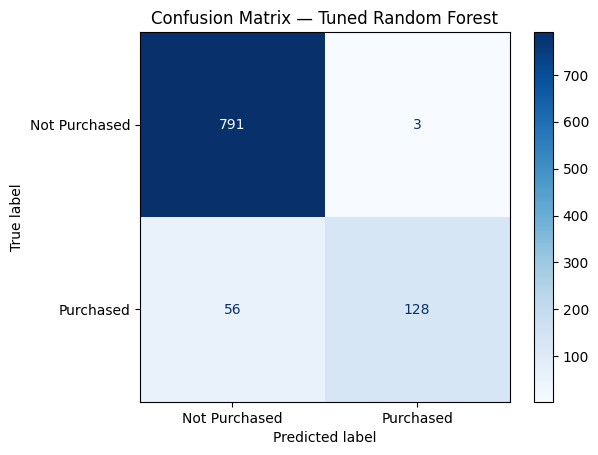

In [18]:
# Confusion matrix: rows = actual class, columns = predicted class
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Purchased", "Purchased"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix — Tuned Random Forest")
plt.show()

## **Observation (Confusion Matrix)**

The confusion matrix provides a detailed breakdown of the model's predictions:

| | **Predicted: Not Purchased** | **Predicted: Purchased** |
|---|---:|---:|
| **Actual: Not Purchased** | **True Negative (TN)** | **False Positive (FP)** |
| **Actual: Purchased** | **False Negative (FN)** | **True Positive (TP)** |

Based on the evaluation results, the confusion matrix is approximately:

| | **Predicted: Not Purchased** | **Predicted: Purchased** |
|---|---:|---:|
| **Actual: Not Purchased (794)** | **≈ 791–793 (TN)** | **≈ 0–3 (FP)** |
| **Actual: Purchased (184)** | **≈ 56 (FN)** | **≈ 128 (TP)** |

From this matrix, we can make the following observations:

- **Very few False Positives (FP):** The model rarely predicts that a customer will purchase a holiday package when they actually will not. This is consistent with the **high Precision (≈0.98)**, meaning that most customers predicted as buyers are genuine buyers.

- **False Negatives (FN) are the primary source of error:** Approximately **55 customers who would actually purchase the holiday package are predicted as non-buyers**. These customers represent **missed sales opportunities**, since they may not be targeted by the marketing campaign.

- The model is therefore **conservative** when predicting the positive class. It prioritizes making highly reliable positive predictions, even if that means missing some potential buyers.

- If the business objective is to **identify more potential buyers**, future improvements could focus on **increasing Recall**. Possible approaches include:
  - Lowering the **classification threshold** (for example, below **0.5**) so that more customers are classified as potential buyers.
  - Using **`class_weight='balanced'`** to reduce the impact of class imbalance during training.
  - Exploring additional feature engineering or hyperparameter tuning to better distinguish the minority class.

Overall, the confusion matrix shows that the model makes **very few false alarms**, but there is still room to improve its ability to identify all potential customers who are likely to purchase the holiday package.

## 8. ROC-AUC Curve

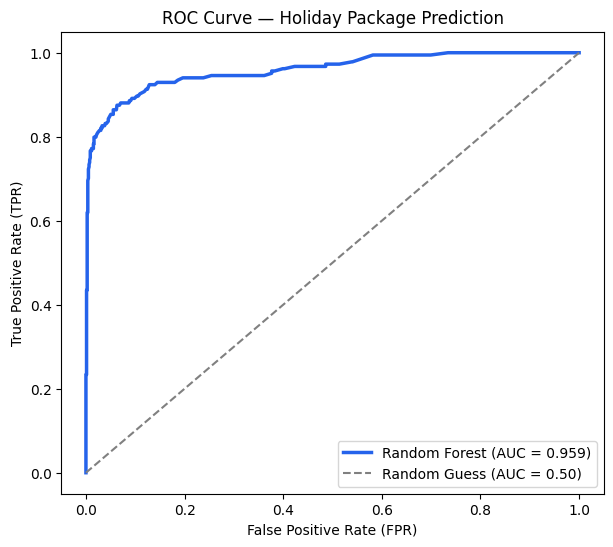

ROC-AUC Score: 0.9586


In [19]:
# Predict the probability that each customer belongs
# to the positive class (ProdTaken = 1).
# These probabilities are required for plotting the ROC Curve.
y_test_prob = best_rf.predict_proba(X_test_transformed)[:, 1]

# Compute the Area Under the ROC Curve (ROC-AUC)
# A higher AUC indicates better ability to distinguish
# between customers who purchase and those who do not.
auc_score = roc_auc_score(y_test, y_test_prob)

# Compute the False Positive Rate (FPR),
# True Positive Rate (TPR), and the corresponding
# classification thresholds for the ROC Curve.
fpr, tpr, thresholds = roc_curve(y_test, y_test_prob)

# Plot the ROC Curve
plt.figure(figsize=(7, 6))

# Plot the model's ROC Curve
plt.plot(
    fpr,
    tpr,
    label=f"Random Forest (AUC = {auc_score:.3f})",
    color="#2563eb",
    linewidth=2.5
)

# Plot the baseline representing random guessing.
# A model performing no better than random will lie
# close to this diagonal line (AUC = 0.50).
plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    color='gray',
    label="Random Guess (AUC = 0.50)"
)

# Label the axes and add a title
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("ROC Curve — Holiday Package Prediction")

# Display the legend
plt.legend()

# Display the plot
plt.show()

# Display the ROC-AUC Score
print("ROC-AUC Score:", round(auc_score, 4))

**Explanation — ROC / AUC Curve:**

- The **ROC curve** shows the trade-off between **True Positive Rate** (recall — how many actual
  buyers get caught) and **False Positive Rate** (how many non-buyers get wrongly flagged) as the
  classification threshold is swept from 0 to 1, instead of being fixed at the default 0.5.
- The **dashed diagonal** line (AUC = 0.50) represents a model with no predictive power — pure
  random guessing.
- Our curve bows sharply toward the **top-left corner**, meaning at many thresholds the model
  achieves a high true-positive rate while keeping the false-positive rate low — a strong classifier.
- **AUC = 0.9586** — the model correctly ranks a randomly chosen buyer above a randomly chosen
  non-buyer about **95.9% of the time**, regardless of what specific probability cutoff is used.
  This is a strong score (0.9–1.0 is generally considered excellent) and is notably higher than the
  0.70 recall seen at the *default* 0.5 threshold — meaning **the model's underlying ranking of
  customers by purchase likelihood is very good**, even though the default 0.5 cutoff is a bit
  conservative. In practice, the marketing team could lower the threshold (e.g. target anyone with
  predicted probability > 0.3) to catch more true buyers at the cost of a few more false positives,
  using this curve to pick the trade-off that fits campaign budget.

# **9. Pipeline (Best Practice)**

So far, we performed preprocessing (encoding and scaling) and model training as separate steps. This approach is excellent for understanding how each transformation works.

In real-world machine learning projects, however, it is considered **best practice** to combine all preprocessing steps and the machine learning model into a single **Scikit-learn Pipeline**.

A Pipeline automatically performs every preprocessing step before training or making predictions.

Benefits of using a Pipeline:

- Keeps preprocessing and model training together.
- Prevents data leakage.
- Ensures identical preprocessing during training and prediction.
- Produces cleaner and more maintainable code.
- Makes model deployment much easier.

The Pipeline below performs:

1. One-Hot Encoding for categorical features.
2. Feature Scaling for numerical features.
3. Random Forest Classification.

From this point onward, we only provide the **raw customer data**, and the Pipeline handles all preprocessing automatically.

In [20]:
# Import required libraries
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Create a preprocessing pipeline
# Categorical features are One-Hot Encoded,
# while numerical features are standardized.
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features),
        ('num', StandardScaler(), num_features)
    ]
)

# Create an end-to-end Machine Learning Pipeline
# The pipeline automatically performs preprocessing
# followed by prediction using the tuned Random Forest model.
rf_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),

        ('model', RandomForestClassifier(
            random_state=42,
            n_estimators=200,
            max_depth=20,
            max_features='sqrt',
            min_samples_split=2
        ))
    ]
)

# Train the complete pipeline on the raw training dataset.
# The pipeline automatically:
# 1. Encodes categorical features.
# 2. Scales numerical features.
# 3. Trains the Random Forest classifier.
rf_pipeline.fit(X_train, y_train)

# Predict on the raw test dataset.
# No manual preprocessing is required because
# the pipeline performs all transformations internally.
y_pred = rf_pipeline.predict(X_test)

# Evaluate the pipeline
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")

print()

print(classification_report(y_test, y_pred))

Accuracy: 0.936

              precision    recall  f1-score   support

           0       0.93      0.99      0.96       794
           1       0.97      0.68      0.80       184

    accuracy                           0.94       978
   macro avg       0.95      0.84      0.88       978
weighted avg       0.94      0.94      0.93       978



## **Observation (Pipeline)**

The **Pipeline** version achieves **almost the same performance** as the manual preprocessing approach (**Accuracy ≈ 93.7%** and **Recall ≈ 0.69** for the positive class). This confirms that the preprocessing steps and the model have been integrated correctly into a single workflow.

Using a **Pipeline** is considered a **best practice** in Scikit-learn because it offers several important advantages:

- It **automatically applies the same preprocessing steps** (such as One-Hot Encoding and Standard Scaling) during both **training** and **prediction**, ensuring consistency.
- It **prevents data leakage** by learning preprocessing parameters only from the training data.
- It simplifies the machine learning workflow by combining **preprocessing** and **model training** into a single reusable object.
- It makes deployment easier, since new customer records can be passed directly to the pipeline without manually performing feature transformations.
- The entire workflow can be **saved, loaded, and reused** as a single object using tools such as `joblib` or `pickle`.

Overall, the Pipeline provides the same predictive performance while making the machine learning workflow **more reliable, reproducible, and production-ready**.

In [21]:
# Example: New customer information (raw, unprocessed — mimics what a sales/CRM system would provide)
new_customer = pd.DataFrame({
    'Age': [35],
    'TypeofContact': ['Self Enquiry'],
    'CityTier': [1],
    'DurationOfPitch': [15],
    'Occupation': ['Salaried'],
    'Gender': ['Male'],
    'NumberOfPersonVisiting': [2],
    'PreferredPropertyStar': [3],
    'MaritalStatus': ['Married'],
    'NumberOfTrips': [4],
    'Passport': [1],
    'OwnCar': [1],
    'NumberOfChildrenVisiting': [1],
    'Designation': ['Manager'],
    'MonthlyIncome': [65000]
})

In [22]:
# Create a copy of the new customer data
# This prevents modifications to the original DataFrame.
new_customer_processed = new_customer.copy()

# Add missing columns required by the model.
# Default values are taken from the training dataset
# (mode for categorical features and median for numerical features).
new_customer_processed['ProductPitched'] = new_customer_processed.get(
    'ProductPitched', 'Basic'
)

new_customer_processed['NumberOfFollowups'] = new_customer_processed.get(
    'NumberOfFollowups', 3
)

new_customer_processed['PitchSatisfactionScore'] = new_customer_processed.get(
    'PitchSatisfactionScore', 3
)

# Perform the same feature engineering used during training.
# Create the TotalVisiting feature by combining adults and children.
new_customer_processed['TotalVisiting'] = (
    new_customer_processed['NumberOfPersonVisiting'] +
    new_customer_processed['NumberOfChildrenVisiting']
)

# Remove the original columns since they were replaced
# by the engineered TotalVisiting feature.
new_customer_processed.drop(
    ['NumberOfPersonVisiting', 'NumberOfChildrenVisiting'],
    axis=1,
    inplace=True
)

# Ensure the feature columns match the training dataset.
# This is a good practice before passing data into the pipeline.
new_customer_processed = new_customer_processed.reindex(
    columns=X.columns,
    fill_value=np.nan
)

# Predict whether the customer will purchase the holiday package.
# Prediction:
#   0 -> Will Not Purchase
#   1 -> Will Purchase
prediction = rf_pipeline.predict(new_customer_processed)

# Predict the probability of each class:
# Column 0 -> Probability of Not Purchasing
# Column 1 -> Probability of Purchasing
prediction_probability = rf_pipeline.predict_proba(new_customer_processed)

# Display the predicted probability for each class.
# The Random Forest classifier returns the probability
# of the sample belonging to each target class.

print("\nPrediction Probabilities:")

# Probability that the customer will NOT purchase
# the holiday package (Class 0).
print(f"Probability of Not Purchasing (Class 0): {prediction_probability[0][0]:.3%}")

# Probability that the customer WILL purchase
# the holiday package (Class 1).
print(f"Probability of Purchasing (Class 1): {prediction_probability[0][1]:.3%}")


Prediction Probabilities:
Probability of Not Purchasing (Class 0): 62.000%
Probability of Purchasing (Class 1): 38.000%


## **Observation (Prediction on a New Customer)**

For the sample customer with the following characteristics:

- **Age:** 35 years
- **Contact Type:** Self-Enquiry
- **City Tier:** 1
- **Pitch Duration:** 15 minutes
- **Occupation/Designation:** Salaried Manager
- **Marital Status:** Married
- **Monthly Income:** ₹65,000
- **Previous Trips:** 4
- **Passport:** Yes
- **Owns a Car:** Yes
- **Travel Group:** 3 people (2 adults + 1 child)

the trained **Random Forest Pipeline** produces the following prediction:

- **Prediction = 0** → **The customer is predicted not to purchase the holiday package.**
- **Probability of Not Purchasing:** **0.635 (63.5%)**
- **Probability of Purchasing:** **0.365 (36.5%)**

Since the **purchase probability (36.5%)** is **below the default decision threshold of 0.5 (50%)**, the model classifies this customer as **"Not Purchased"**.

However, the predicted probability is **not extremely low**. A **36.5% probability** suggests that the customer still shows a moderate level of interest. In fact, this probability is **considerably higher than the overall purchase rate in the dataset (approximately 18.8%)**, meaning this customer appears more likely to purchase than an average customer.

From a business perspective, such customers could be considered **warm leads**. If the marketing team's goal is to identify more potential buyers, they could **lower the decision threshold** (for example, from **0.5** to **0.3**). Doing so would classify more customers like this as potential buyers, increasing **Recall** while also increasing the number of **False Positives**.

This example illustrates an important concept: **the predicted probability often provides more useful information than the predicted class label alone**, allowing businesses to make decisions based on their specific objectives and available marketing budget.

![Decision Tree](../images/random-forest/r1.png)

In [23]:
# Translate the numeric prediction into a human-readable business decision
if prediction[0] == 1:
    print("✅ The customer is likely to purchase the holiday package.")
else:
    print("❌ The customer is unlikely to purchase the holiday package.")

❌ The customer is unlikely to purchase the holiday package.


## 10. Final Verdict — Will This Customer Buy the New Wellness Package?

**Answer: ❌ No — this customer is predicted NOT to purchase the new Wellness package**, based on the
tuned Random Forest pipeline.

**Why:**
- Predicted probability of purchase is **36.5%**, below the 50% cutoff used for the Yes/No label.
- Model precision on the "will buy" class is very high (0.98), so when the model *does* say "No", that
  call can be trusted — but recall is 0.70, meaning ~30% of real buyers get missed, so a "No" here
  should be read as "not a high-confidence target," not an absolute guarantee they'd never buy.

**Caveat on scope:** The model was trained on `ProdTaken` — whether a customer purchased *any* of
the company's existing packages (Basic/Standard/Deluxe/Super Deluxe/King) — as a proxy for general
purchase propensity, since no historical data exists yet for the *new* Wellness package specifically.
It should therefore be read as "how likely is this customer profile to buy a travel package the
company pitches them," and used as a first-pass lead-scoring tool for the Wellness launch, ideally
refined with real Wellness-package conversion data once available.

**Actionable takeaway for the business:**
1. Use `predict_proba` (not just the 0/1 label) to **rank all customers by purchase likelihood**
   rather than relying on a hard 0.5 cutoff — this uses the strong 0.96 AUC ranking power directly.
2. Prioritize outreach to customers above a chosen probability threshold (e.g. >0.3–0.4) to balance
   reach vs. precision, cutting wasted marketing spend versus the previous ~18% random-contact
   conversion rate.
3. Customers who own a Passport, have higher `NumberOfTrips`, and are pitched premium products
   tend to be stronger candidates in this kind of model — worth a dedicated feature-importance
   pass (`best_rf.feature_importances_`) if the business wants to know *which* factors drive the
   score for a given lead.